## **Simulation Analysis**

This notebook contains a selection of plots and other analyses of the simulations conducted in run_simulation.py. Please ensure that the simulations are complete before executing this notebook.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scripts.plot_osc import *
import os
import pandas as pd
from scripts.bat_class import BatOsc, Ball, bat_from_pkl, ball_from_pkl, ball_from_json, bat_from_json
from scripts.unit_conversions import *
from scripts.plot_osc import plot_ball_forces

In [3]:
import json

bat_json_paths = {
    'AdleyOld': 'data/bats/AdleyOld.json',
    'AdleyNewMod2': 'data/bats/AdleyNewMod2.json',
}

bat_json_data = {}
for name, path in bat_json_paths.items():
    with open(path, 'r') as f:
        bat_json_data[name] = json.load(f)

# Rows are JSON references; transpose so index becomes JSON parameter keys
df = pd.DataFrame.from_dict(bat_json_data, orient='index').T
df.index.name = 'parameter'
print(df.to_latex())

\begin{tabular}{lll}
\toprule
 & AdleyOld & AdleyNewMod2 \\
parameter &  &  \\
\midrule
name & standard & torpedo \\
profile_file & data/bats/AdleyOld.dat & data/bats/AdleyNewMod2.dat \\
bat_length & 0.860000 & 0.860000 \\
mass & 0.890175 & 0.908319 \\
rho & 690 & 690 \\
Y & 16400000000.000000 & 16500000000.000000 \\
S & 1000000000.000000 & 900000000.000000 \\
dz & 0.010000 & 0.010000 \\
\bottomrule
\end{tabular}



## **Load Results**

In [4]:
sim_key = 'Adley' #unique identifier for the simulation, used to load the correct files
standard_path = f'results/{sim_key}_stan_results.csv'
torp_path = f'results/{sim_key}_torp_results.csv'

standard_df = pd.read_csv(standard_path)
torp_df = pd.read_csv(torp_path)

In [5]:
#load ball params
ball_params_path = f'data/balls/{sim_key}_ball.json'
ball_params = ball_from_json(ball_params_path)
#convert ztip to cm from knob

In [6]:
#Alan results
fname = 'data/bats/AdleyBats.csv'
alan_df = pd.read_csv(fname)
alan_df.rename(columns={'vf/vi-1': 'standard', 'vf/vi-2': 'torp'}, inplace=True)

L = max(standard_df['idx']*1e-2)
alan_df['z'] = L - inches_to_m(alan_df['ztip'].values) 

In [7]:
standard_df['vf_vi'] = standard_df['vf'] / ball_params.initial_velocity
torp_df['vf_vi'] = torp_df['vf'] / ball_params.initial_velocity

In [57]:
#highest 20 pct of vf_vi values both each bats, where are the collisions?

combined_top20 = np.percentile(pd.concat([standard_df['vf_vi'], torp_df['vf_vi']]), 80)
standard_df['sweet_spot'] = standard_df['vf_vi'] >= combined_top20
print('Sweet spot is where vf/vi is above:', combined_top20)

standard_sweet_spot = min(standard_df.loc[standard_df['sweet_spot'], 'ztip']), max(standard_df.loc[standard_df['sweet_spot'], 'ztip'])
print(f"Standard sweet spot range (inches from tip): {standard_sweet_spot}")
standard_ss_width = standard_sweet_spot[1] - standard_sweet_spot[0]
print(f"Standard sweet spot width (inches): {standard_ss_width:.2f}")


torp_top20 = torp_df['vf_vi'].quantile(0.8)
torp_df['sweet_spot'] = torp_df['vf_vi'] >= combined_top20
torp_sweet_spot = min(torp_df.loc[torp_df['sweet_spot'], 'ztip']), max(torp_df.loc[torp_df['sweet_spot'], 'ztip'])
print(f"Torpedo sweet spot range (inches from tip): {torp_sweet_spot}")
torp_ss_width = torp_sweet_spot[1] - torp_sweet_spot[0]
print(f"Torpedo sweet spot width (inches): {torp_ss_width:.2f}")

Sweet spot is where vf/vi is above: 0.22356556511673417
Standard sweet spot range (inches from tip): (5.905500000000001, 8.267699999999998)
Standard sweet spot width (inches): 2.36
Torpedo sweet spot range (inches from tip): (5.905500000000001, 8.661399999999999)
Torpedo sweet spot width (inches): 2.76


In [58]:
inches_to_m(torp_ss_width - standard_ss_width)

0.010000000000000021

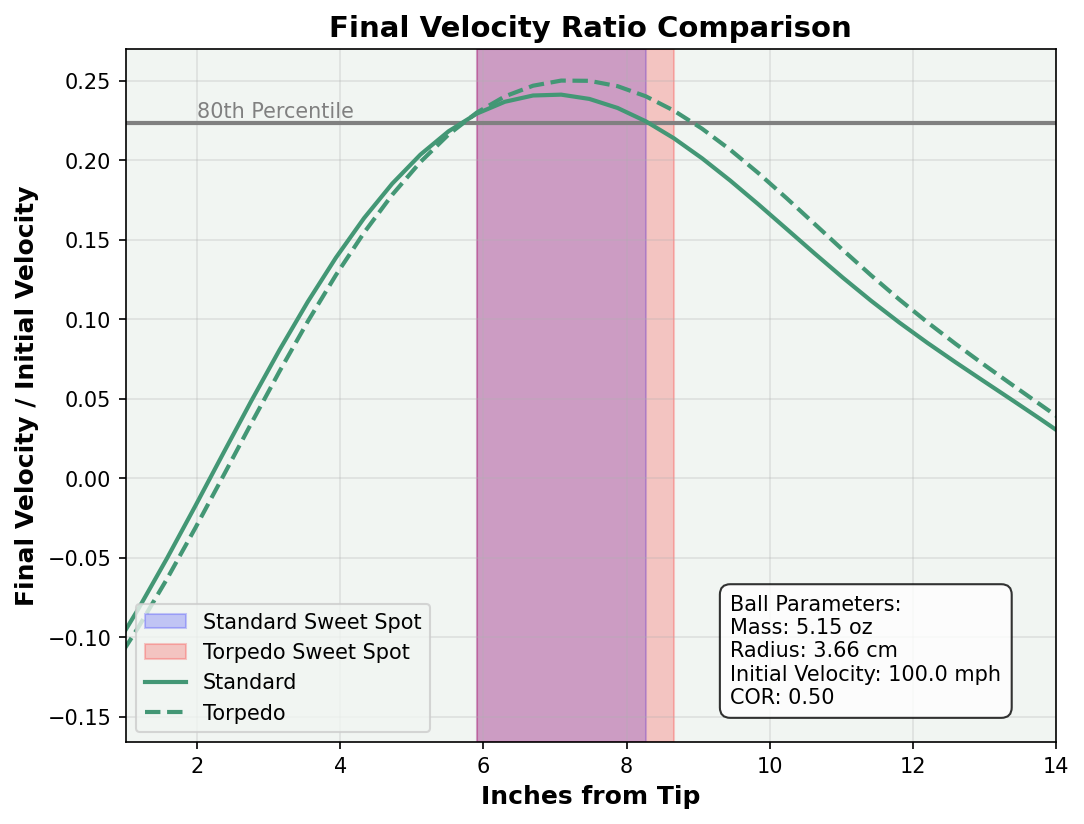

In [59]:
fig, ax = plt.subplots(figsize=(8,6))

#add sweet spot boxes
plt.axvspan(standard_sweet_spot[0], standard_sweet_spot[1], color='blue', alpha=0.2, label='Standard Sweet Spot')
plt.axvspan(torp_sweet_spot[0], torp_sweet_spot[1], color='red', alpha=0.2, label='Torpedo Sweet Spot')
plt.axhline(combined_top20, color='gray')
ax.text(2, combined_top20 + 0.001, '80th Percentile', color='gray', ha='left', va='bottom')

plt.plot(standard_df['ztip'], standard_df['vf_vi'], label='Standard', color = colors[1])
plt.plot(torp_df['ztip'], torp_df['vf_vi'], label='Torpedo', color = colors[1], linestyle = '--')
# plt.plot(alan_df['ztip'], alan_df['standard'], label='Alan Standard', color = 'k', linestyle = '--')
# plt.plot(alan_df['ztip'], alan_df['torp'], label='Alan Torpedo', color = 'r', linestyle = '--')

#add box on top left with ball params
ball_params_text = f"Ball Parameters:\nMass: {kg_to_oz(ball_params.mass):.2f} oz\nRadius: {ball_params.radius*1e2:.2f} cm\nInitial Velocity: {mps_to_mph(ball_params.initial_velocity):.1f} mph\nCOR: {ball_params.e0:.2f}"
plt.text(0.65, 0.05, ball_params_text, transform=ax.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='left', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))


plt.xlabel('Inches from Tip')
plt.ylabel('Final Velocity / Initial Velocity')
plt.title('Final Velocity Ratio Comparison')
plt.legend(loc = 'lower left')
plt.xlim(1, 14)
plt.savefig('plots/final_velocity_comparison.pdf')
plt.show()

In [60]:
#differences
diff = np.mean(torp_df['vf_vi'] - standard_df['vf_vi'])
print(f"Average increase in vf/vi from standard to torpedo: {diff:.4f}")

Average increase in vf/vi from standard to torpedo: 0.0038


In [61]:
#load bat params
standard_bat = bat_from_json(f'data/bats/AdleyOld.json')
torpedo_bat = bat_from_json(f'data/bats/AdleyNewMod2.json')

#load ball params
ball = ball_from_json(f'data/balls/{sim_key}_ball.json')

/Users/navawolfish/Desktop/baseball/AlanProject/scripts/eigenstuff.py:23: RuntimeWarning: invalid value encountered in sqrt
  'frequency_Hz': np.where(evals.real < 0, np.sqrt(-evals.real) / (2 * np.pi), 0),


In [62]:
#rigid expectation - standard bat
slice_vols = standard_bat.dz * np.pi * (standard_bat.radii)**2 # volume of each slice based on its geometry
slice_masses = standard_bat.dz * standard_bat.rho * np.pi * (standard_bat.radii)**2 # mass of each slice based on its volume and density
M = np.sum(slice_masses) # total mass of the bat by summing the masses of all slices

z = standard_bat.zs[standard_df['idx']] # z coordinate of the impact location

#center of mass and moment of inertia calculations
zcm = np.sum(slice_masses * standard_bat.zs) / M
Icm = np.sum(0.25*slice_masses * (standard_bat.radii)**2 + slice_masses * (standard_bat.zs - zcm)**2) 

#EQ 8 FROM PAPER
inv_Meff = 1/M + (z - zcm) ** 2 / Icm
Meff = 1 / inv_Meff
r_standard = ball.mass / Meff #bat recoil factor

#expected velo
standard_df['e_COR'] = standard_df['vf_vi'] * (1 + r_standard) + r_standard

In [63]:
#rigid expectation - torpedo
slice_vols = torpedo_bat.dz * np.pi * (torpedo_bat.radii)**2 # volume of each slice based on its geometry
slice_masses = torpedo_bat.dz * torpedo_bat.rho * np.pi * (torpedo_bat.radii)**2 # mass of each slice based on its volume and density
M = np.sum(slice_masses) # total mass of the bat by summing the masses of all slices

z = torpedo_bat.zs[torp_df['idx']] # z coordinate of the impact location
zcm = np.sum(slice_masses * torpedo_bat.zs) / M
Icm = np.sum(0.25*slice_masses * (torpedo_bat.radii)**2 + slice_masses * (torpedo_bat.zs - zcm)**2) 

#EQ 8 FROM PAPER
inv_Meff = 1/M + (z - zcm) ** 2 / Icm
Meff = 1 / inv_Meff
r_torp = ball.mass / Meff #bat recoil factor
#expected velo
torp_df['e_COR'] = torp_df['vf_vi'] * (1 + r_torp) + r_torp

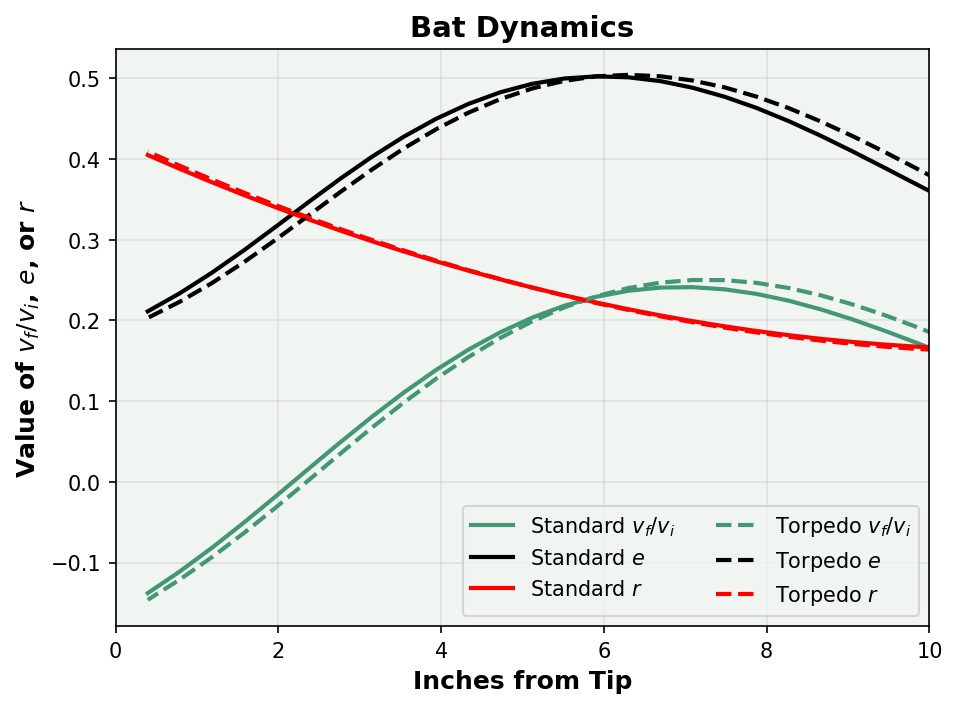

In [78]:
## Recreating Fig 2 from Nathan 2002
plt.figure(figsize=(7,5))
plt.plot(standard_df['ztip'], standard_df['vf_vi'], label='Standard $v_f/v_i$', color = colors[1])
plt.plot(standard_df['ztip'], standard_df['e_COR'], label='Standard $e$', color = 'k', )
plt.plot(standard_df['ztip'], r_standard, color = 'r', label='Standard $r$')
plt.plot(standard_df['ztip'], torp_df['vf_vi'], label='Torpedo $v_f/v_i$', color = colors[1], linestyle = '--')
plt.plot(standard_df['ztip'], torp_df['e_COR'], label='Torpedo $e$', color = 'k', linestyle = '--')
plt.plot(standard_df['ztip'], r_torp, color = 'r', label='Torpedo $r$', linestyle = '--')
plt.xlabel('Inches from Tip')
plt.ylabel('Value of $v_f/v_i$, $e$, or $r$')
plt.title('Bat Dynamics')
plt.legend(ncols = 2)
plt.xlim(0, 10)
plt.savefig('plots/bat_dynamics.pdf')

## **Sample Plots for Report**

In [65]:
#hysteresis curve

#run sample simulation for standard bat
sim = bat_from_json(f'data/bats/AdleyOld.json')
inits = np.zeros((4*sim.N))
sim.set_initial_conditions(inits)
ball = ball_from_json(f'data/balls/Adley_ball.json')
sim.ball = ball

t_span = (0, 0.02)
t_eval = np.linspace(0, t_span, 10000)

sol = sim.integrate_with_ball(ball = ball, impact_idx=78, t_span=t_span, t_eval=t_eval)

/Users/navawolfish/Desktop/baseball/AlanProject/scripts/eigenstuff.py:23: RuntimeWarning: invalid value encountered in sqrt
  'frequency_Hz': np.where(evals.real < 0, np.sqrt(-evals.real) / (2 * np.pi), 0),


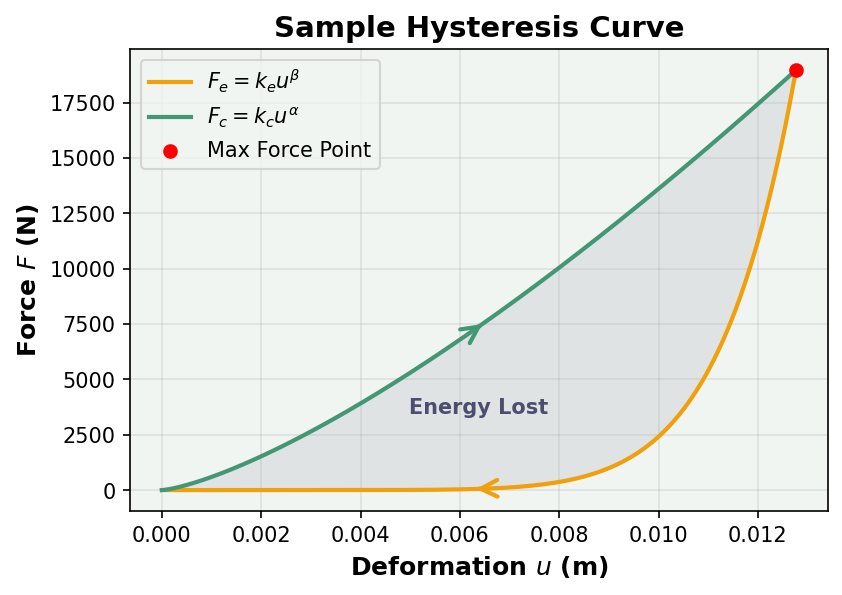

In [66]:
plot_ball_forces(ball, title = 'Sample Hysteresis Curve')

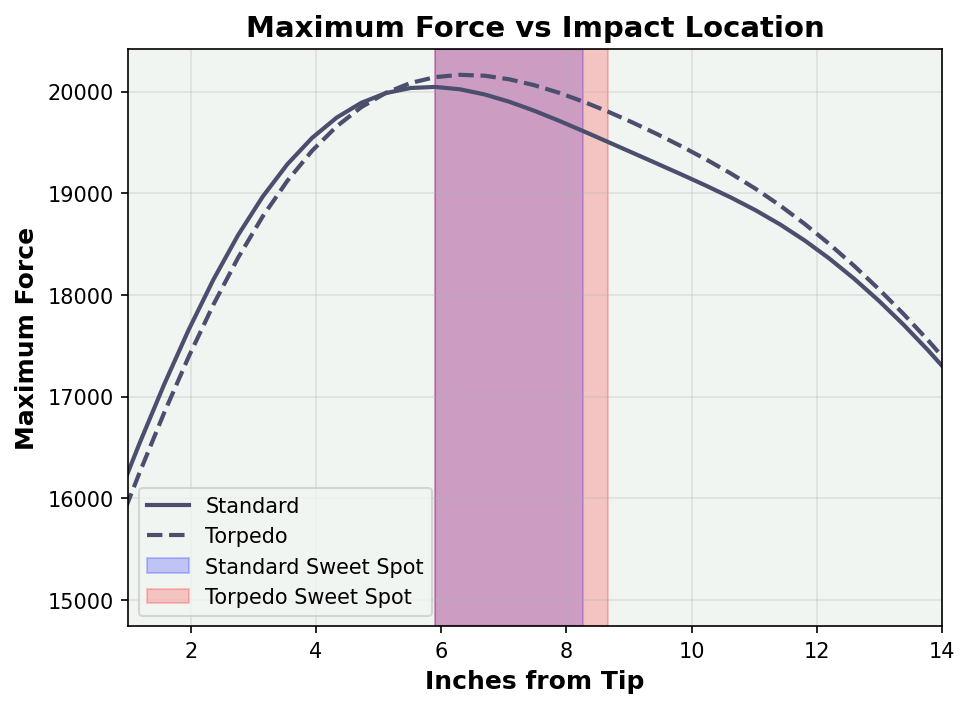

In [76]:
plt.subplots(figsize=(7,5))
plt.plot(standard_df['ztip'], standard_df['max_F'], label='Standard', color = colors[2])
plt.plot(torp_df['ztip'], torp_df['max_F'], label='Torpedo', color = colors[2], linestyle = '--')
# plt.scatter(standard_df.loc[np.argmax(standard_df['max_F']), 'ztip'], np.max(standard_df['max_F']), color = colors[2], s=10)
# plt.scatter(torp_df.loc[np.argmax(torp_df['max_F']), 'ztip'], np.max(torp_df['max_F']), color = colors[2], s=10)
# #add sweet spots
plt.axvspan(standard_sweet_spot[0], standard_sweet_spot[1], color='blue', alpha=0.2, label='Standard Sweet Spot')
plt.axvspan(torp_sweet_spot[0], torp_sweet_spot[1], color='red', alpha=0.2, label='Torpedo Sweet Spot')


plt.xlim(1, 14)
plt.xlabel('Inches from Tip')
plt.ylabel('Maximum Force')
plt.legend()
plt.title('Maximum Force vs Impact Location')
plt.savefig('plots/max_force_comparison.pdf')
plt.show()

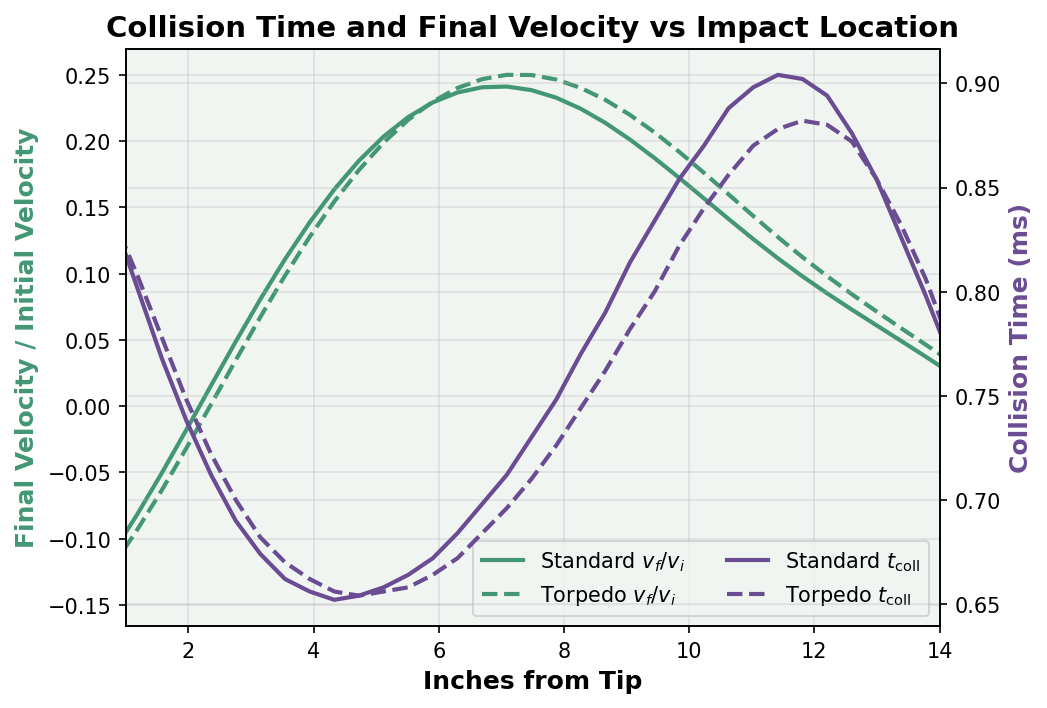

In [68]:
fig, ax1 = plt.subplots(figsize=(7,5))
ax2 = ax1.twinx()

# Left axis: final velocity ratio
line1 = ax1.plot(standard_df['ztip'], standard_df['vf_vi'], label=r'Standard $v_f/v_i$', color=colors[1])
line2 = ax1.plot(torp_df['ztip'], torp_df['vf_vi'], label=r'Torpedo $v_f/v_i$', color=colors[1], linestyle='--')

# Right axis: collision time
line3 = ax2.plot(standard_df['ztip'], standard_df['coll_t'] * 1e3, label=r'Standard $t_\mathrm{coll}$', color=colors[3])
line4 = ax2.plot(torp_df['ztip'], torp_df['coll_t'] * 1e3, label=r'Torpedo $t_\mathrm{coll}$', color=colors[3], linestyle='--')

ax1.set_xlabel('Inches from Tip')
ax1.set_ylabel('Final Velocity / Initial Velocity', color=colors[1])
ax2.set_ylabel('Collision Time (ms)', color=colors[3])
ax1.set_xlim(1, 14)
ax1.set_title('Collision Time and Final Velocity vs Impact Location')

lines = line1 + line2 + line3 + line4
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, ncols = 2, loc = 'lower right')
plt.show()

In [69]:
# %% Set up time span for simulation
tspan = (0, 0.02) #time span for simulation
N_time = 10000
t_eval = np.linspace(tspan[0], tspan[1], N_time) #time points 
dt = t_eval[1] - t_eval[0]